## 13장. 연습문제

In [1]:
#필요한 모듈 import
import warnings #출력창에서 경고문구를 무시

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)


In [2]:
# 데이터를 가져오기
df = pd.read_excel("사과-군집화.xlsx")
df.drop(columns=['kind','region'], inplace=True)

### 3번

In [3]:
import numpy as np
import pandas as pd

df = pd.read_excel("사과-군집화.xlsx")
df.drop(columns=['kind','region'], inplace=True)

from sklearn.cluster import KMeans

model1 = KMeans(n_clusters=5, random_state=0) 
model1.fit(df)    

KMeans(n_clusters=5, random_state=0)

### 4번

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_excel("사과-군집화.xlsx")
df.drop(columns=['kind','region'], inplace=True)
model1 = KMeans(n_clusters=5, random_state=0) 
model1.fit(df)    

df_c1 = df.copy()
df_c1['cluster'] = model1.labels_
df_c1

,weight,height,width,sugar,sour,cluster
0,283.6,78.3,87.0,13.0,0.39,4
1,229.0,73.9,81.6,11.4,0.29,0
2,266.5,73.9,86.1,12.3,0.37,0
3,176.7,66.8,73.7,11.0,0.31,3
4,308.6,83.3,90.7,15.2,0.19,4
...,...,...,...,...,...,...
71,384.2,85.9,96.4,14.1,0.51,2
72,311.3,82.9,90.5,12.7,0.25,1
73,284.3,78.2,88.0,13.6,0.36,4
74,324.0,88.4,92.1,12.6,0.22,1


### 5번

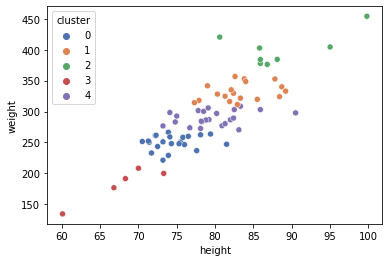

In [5]:
sns.scatterplot(data = df_c1, x='height',y='weight',hue='cluster',palette='deep')
plt.show()

### 6번

In [6]:
from sklearn.metrics import silhouette_samples,silhouette_score

avg_score = silhouette_score(df, model1.labels_)
print('평균 실루엣 계수 =',avg_score)

평균 실루엣 계수 = 0.5292914473579787


In [7]:
print('평균 실루엣 계수 =',avg_score)
samples = silhouette_samples(df, model1.labels_)
score_df = pd.DataFrame({'cluster':model1.labels_, 'silhouette':samples})
score_df.groupby('cluster').describe()

평균 실루엣 계수 = 0.5292914473579787


silhouette                                                    \
             count      mean       std       min       25%       50%   
cluster                                                                
0             22.0  0.601672  0.154277  0.235150  0.520720  0.647271   
1             18.0  0.508239  0.183265  0.020278  0.416558  0.557395   
2              8.0  0.536002  0.102015  0.372794  0.471253  0.552346   
3              5.0  0.464398  0.162378  0.198226  0.454564  0.481058   
4             23.0  0.488306  0.194997  0.074376  0.384353  0.547157   

                             
              75%       max  
cluster                      
0        0.725827  0.746133  
1        0.657845  0.687201  
2        0.615244  0.652765  
3        0.576531  0.611609  
4        0.653698  0.697182